### Buid A basic chat bot with langraph (Graph API)

In [3]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages #recducer


In [4]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    
    messages: Annotated[list, add_messages]

graph_builder =StateGraph(State)

In [5]:
graph_builder

In [6]:
import os 
from dotenv import load_dotenv
load_dotenv()
#os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


True

In [29]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-20b")

In [30]:
# we also do like _>
# llm = init_chat_model("groq:llama-3.1-8b-instant")

In [40]:
# Node functionality 
def chatbot(state):
    return {"messages":[llm.invoke(state["messages"])]}


In [41]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)

## Adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph = graph_builder.compile()

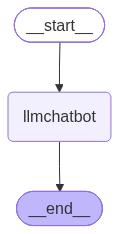

In [42]:
## visulization
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [43]:
responce=graph.invoke({"messages":"Hi how are you"})

In [44]:
responce["messages"][-1]

AIMessage(content='Hello! I’m doing well—thanks for asking. How about you? Anything interesting happening today?', additional_kwargs={'reasoning_content': 'The user says "Hi how are you". It\'s a greeting. We should respond politely, maybe ask how they\'re doing. It\'s a simple conversation. No special instructions. The user didn\'t ask for anything. So respond with friendly tone.'}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 75, 'total_tokens': 151, 'completion_time': 0.093129628, 'completion_tokens_details': {'reasoning_tokens': 47}, 'prompt_time': 0.003593324, 'prompt_tokens_details': None, 'queue_time': 0.201265443, 'total_time': 0.096722952}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_63473661d7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a06270-bb9e-7143-b5fa-72ba78520f4e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_t